# Week 2

Hvordan man altid finder dimensionen fra $n$

In [1]:
import sympy as sp 
m , n = sp.symbols('m n', real=True, integer=True, positive=True)


expr = sp.Eq(m * (m-1), n)

solution = sp.solve(expr, m)
print(solution)

[1/2 - sqrt(4*n + 1)/2, sqrt(4*n + 1)/2 + 1/2]


$$
n = m (m - 1) = m^2 - m
$$

$$
m^2 -m -n = 0
$$
where $b=-
1$, $a =1$, $c=-n$

s.t. 
$D = 1 - 4*1*(-n) = 4n + 1$ 

$$
\lambda_p = \frac{1 + \sqrt{4n + 1}}{2}
$$

$$
= \frac{1 + \sqrt{4n + 1}}{2}
$$

### Testing Models of week 2

The goal of this week is to compute 4 different models and test them on a series of a year of data. The following models we want to create is: 

1. StationaryHMM: This models assumes a homogen markov chain for modelliing CO2. 
2. HMMAR: This models a assumes autoregression between observations of steps k 
3. CovarHMM: This models assumes a inhomogen markov chain, meaning that the transition proberbility matrix changes over time. This is then modelled with covaries. 
4. AR: This models the autoregression between CO2 timesteps. 


All the above models assumes 3 states. 
- State 1 is the the room has been vacant for a long time or the windown have been open. 
- State 3 is the state where there are occupants in the room. 
- State 2 is a transition state between the two states. This can be seen as a person just entered the room or just left. 

All the above models assumes that the background ppm is $\mu_1 = 400$


## Pre setup of optimization of 3 states

In [2]:
import jax.numpy as jnp
import pandas as pd
import jax

from src.data import load_and_aggregate_data 
from src.utils import random_init_hmm_params, professor_init_3state_hmm_params, professor_init_4state_hmm_params
from src.optim.lbfgs import LFBGSOptimizer
from src.optim.loss import negative_log_likelihood 
import numpy as np
from statsmodels.tsa.ar_model import AutoReg

#CONFIG
jax.config.update("jax_enable_x64", True)
num_states = 3
DAYS_OF_DATA = None

#DATA
df = load_and_aggregate_data(no_of_days=DAYS_OF_DATA) #set to -1 for all data or a int for number of days
y = jnp.array(df["CO2C"].values)



idx = 0 

#INIT OF PROFESSOR'S 3 STATE HMM PARAMS
mu0, log_sigma0, tgamma0 = professor_init_3state_hmm_params() 

#FOR STORING OPTIMIZED MODELS
model_dict = {}

tgamma0

Array([[-3., -3.],
       [-3., -3.],
       [-3., -3.]], dtype=float64, weak_type=True)

## Stationary HMM

Goal is to get the excact same values as Jan

In [3]:
import jax.numpy as jnp 
import jaxopt 
import jax

from src.models.v1.stationary_hmm import StationaryHMM 
from src.optim.loss import negative_log_likelihood 
import time


MODEL_TYPE = "stationary_hmm_3_state"
#INIT OF PROFESSOR'S 3 STATE HMM PARAMS
mu0, log_sigma0, tgamma0 = professor_init_3state_hmm_params() 
model3 = StationaryHMM(mu=mu0, log_sigma=log_sigma0, transition_logits=tgamma0) 


### OPTIMIZATION

optimizer = LFBGSOptimizer(loss_fn=negative_log_likelihood, model=model3)

start_time = time.time()
opt_model = optimizer.run(y)
end_time = time.time()

print(f"Optimization for {MODEL_TYPE} took {end_time - start_time:.2f} seconds.")


model_dict[idx] = {
    "name": MODEL_TYPE,
    "model": opt_model,
    "loss": negative_log_likelihood(opt_model, y),
    "X": None
}

idx += 1

loss = negative_log_likelihood(opt_model, y)
print(f"Negative Log Likelihood for {MODEL_TYPE}: {loss:.4f}")

Optimization for stationary_hmm_3_state took 1.78 seconds.
Negative Log Likelihood for stationary_hmm_3_state: 10601.6892


## 4 state model

In [4]:
MODEL_TYPE = "stationary_hmm_4_state"
#INIT OF PROFESSOR'S 4 STATE HMM PARAMS
mu0, log_sigma0, tgamma0 = professor_init_4state_hmm_params() 
model4 = StationaryHMM(mu=mu0, log_sigma=log_sigma0, transition_logits=tgamma0) 

from src.data import save_model_and_data


### OPTIMIZATION

from src.optim.minimizer import Minimizer 

optimizer = Minimizer(loss_fn=negative_log_likelihood, model=model4)

start_time = time.time()
opt_model = optimizer.run(y)
end_time = time.time()

print(f"Optimization for {MODEL_TYPE} took {end_time - start_time:.2f} seconds.")

model_dict[idx] = {
    "name": MODEL_TYPE,
    "model": opt_model,
    "loss": negative_log_likelihood(opt_model, y),
    "X": None
}

idx += 1

loss = negative_log_likelihood(opt_model, y)
print(f"Negative Log Likelihood for {MODEL_TYPE}: {loss:.4f}")

save_model_and_data(modelname="stationary_hmm_4_state", tag="week_2", run=1, model=opt_model, y=y)

Optimization for stationary_hmm_4_state took 0.52 seconds.
Negative Log Likelihood for stationary_hmm_4_state: 10388.6807


LFBGS Optimizatin

In [5]:
### OPTIMIZATION

#optimizer = LFBGSOptimizer(loss_fn=negative_log_likelihood, model=model4)
#
#start_time = time.time()
#opt_model = optimizer.run(y)
#end_time = time.time()
#
#print(f"Optimization for {MODEL_TYPE} took {end_time - start_time:.2f} seconds.")
#
#model_dict[MODEL_TYPE] = opt_model 
#
#loss = negative_log_likelihood(opt_model, y)
#print(f"Negative Log Likelihood for {MODEL_TYPE}: {loss:.4f}")

## Autoregressive Model

We fit the auto regressive model

$$
y_t = c + \phi_1 y_{t-1} + \eta
$$

In [6]:
# Fit AR(2) model
y_np = np.array(y)  # Convert JAX array to NumPy array 
from statsmodels.tsa.arima.model import ARIMA

res = ARIMA(y_np, order=(2, 0, 0)).fit()
print(res.summary())

# Inspect results
print(res.summary())
print("Params")
print(res.params)       # [intercept, phi_1]
print("Negative Log-Likelihood")
print(-res.llf)          # log-likelihood

save_model_and_data(modelname="ar2_model", tag="week_2", run=1, model=res, y=y_np) 

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1666
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -10207.111
Date:                Mon, 16 Mar 2026   AIC                          20422.222
Time:                        22:17:50   BIC                          20443.895
Sample:                             0   HQIC                         20430.254
                               - 1666                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        805.6580     48.949     16.459      0.000     709.719     901.597
ar.L1          1.3033      0.015     84.654      0.000       1.273       1.334
ar.L2         -0.3696      0.011    -33.594      0.0

## ARR HMM

We know fit a Auto regressive model what models the mean. The idea of this is that the mean of the states is dependent on the previous 
observation. 

$$
Y_t \mid (X_t = i, Y_{t-1} = y_{t-1}) = \mu_i + \phi_i(\mu_i - y_{t-1}) + \epsilon_i
$$



In [7]:
from src.models.v1.ar_hmm import ArHMM 

MODEL_TYPE = "arr_hmm"

#INIT OF PARAMS FOR AR-HMM 

phi0 = jnp.array([0.0]*4)  # AR coefficients for each state

tgamma0 = model_dict[idx-1]["model"].transition.transition_logits  # Use transition logits from the optimized 4-state HMM as initialization for AR-HMM
mu0 = model_dict[idx-1]["model"].emission.mu  # Use means from the optimized 4-state HMM as initialization for AR-HMM
log_sigma0 = model_dict[idx-1]["model"].emission.log_sigma  #


model = ArHMM(transition_logits=tgamma0, mu=mu0, log_sigma=log_sigma0, phi=phi0) 

x = jnp.concatenate([jnp.array([1.0]), y[:-1]])  # Lagged observations for AR component 

X = jnp.stack([x,x,x,x], axis=1)  # Same lagged observations for each state, shape (T, num_states) 


### OPTIMIZATION

optimizer = LFBGSOptimizer(loss_fn=negative_log_likelihood, model=model)
#Using Minimze results in a worse likelihood compared to LFBGS, so we use LFBGS for the AR-HMM optimization.

start_time = time.time()
opt_model = optimizer.run(y, X)
end_time = time.time()

print(f"Optimization for {MODEL_TYPE} took {end_time - start_time:.2f} seconds.")

model_dict[idx] = {
    "name": MODEL_TYPE,
    "model": opt_model,
    "loss": negative_log_likelihood(opt_model, y, X),
    "X": X
}

idx += 1


loss = negative_log_likelihood(opt_model, y, X)
print(f"Negative Log Likelihood for {MODEL_TYPE}: {loss:.4f}")

save_model_and_data(modelname="ar_hmm_model", tag="week_2", run=1, model=opt_model, y=y, X=X)

Optimization for arr_hmm took 1.48 seconds.
Negative Log Likelihood for arr_hmm: 9145.6768


In [8]:
opt_model.emission.phi

Array([1.00005795, 1.03787735, 0.7414197 , 0.642594  ], dtype=float64)

In [9]:
opt_model.emission.mu

Array([ 535.68046261,  889.93105469, 1306.70139423], dtype=float64)

## Covariate HMM (Inhomogen Marvkov Chain)

In [10]:
from src.models.v1.covariate_hmm import CovariateHMM 



MODEL_TYPE = "covariate_hmm"
num_states = 4


#DATAPREP
half_hour = df["HalfHour"].values
x1 = jnp.array(jnp.cos(2 * jnp.pi * half_hour / 48))  # Daily cycle
x2 = jnp.array(jnp.sin(2 * jnp.pi * half_hour / 48))  # Daily cycle
X = jnp.stack([x1, x2],axis=1)  # Shape (T, 2) with two covariates


#PARAMETER INIT
beta0 = jnp.array([0.0, 0.0] * num_states)  # Initial beta for covariate effects, shape (num_states * num_covariates,)
beta0 = beta0.reshape(num_states, -1)  # Reshape to (num_states, num_covariates)

inital_state_dist = model_dict[idx-1]["model"].transition.u0()

mu0 = model_dict[idx-1]["model"].emission.mu  # Use optimized means from AR HMM
log_sigma0 = model_dict[idx-1]["model"].emission.log_sigma  # Use
transition_logits0 = model_dict[idx-1]["model"].transition.transition_logits  # Use optimized transition logits from AR HMM 



model = CovariateHMM(transition_logits=transition_logits0, mu=mu0, log_sigma=log_sigma0, initial_state_dist=inital_state_dist, beta=beta0)

### OPTIMIZATION

optimizer = Minimizer(loss_fn=negative_log_likelihood, model=model)

start_time = time.time()
opt_model = optimizer.run(y, X)

end_time = time.time()


print(f"Optimization for {MODEL_TYPE} took {end_time - start_time:.2f} seconds.")


model_dict[idx] = {
    "name": MODEL_TYPE,
    "model": opt_model,
    "loss": negative_log_likelihood(opt_model, y, X),
    "X": X
}

idx += 1


loss = negative_log_likelihood(opt_model, y, X)
print(f"Negative Log Likelihood for {MODEL_TYPE}: {loss:.4f}")

save_model_and_data(modelname="covariate_hmm_model", tag="week_2", run=1, model=opt_model, y=y, X=X)

Optimization for covariate_hmm took 0.53 seconds.
Negative Log Likelihood for covariate_hmm: 10611.7611


## CovariateArHMM

For 4 states

In [11]:
from src.models.v1.covariate_ar_hmm import CovariateArHMM 


#Init of X params for AR covariates 
x = jnp.concatenate([jnp.array([1.0]), y[:-1]])  # Lagged observations for AR component 
X = jnp.stack([x,x,x,x], axis=1)  # Same lagged observations for each state, shape (T, num_states) 
phi_X = X 


half_hour = df["HalfHour"].values
x1 = jnp.array(jnp.cos(2 * jnp.pi * half_hour / 48))  # Daily cycle
x2 = jnp.array(jnp.sin(2 * jnp.pi * half_hour / 48))  # Daily cycle
X_cov = jnp.stack([x1, x2],axis=1)  # Shape (T, 2) with two covariates 


X = jnp.concatenate([phi_X, X_cov], axis=1)  


#PARAMETER INIT
beta0 = model_dict[idx-1]["model"].transition.beta  # Use optimized beta from AR HMM, shape (num_states, num_covariates)

inital_state_dist = model_dict[idx-1]["model"].transition.u0()

mu0 = model_dict[idx-1]["model"].emission.mu  # Use optimized means from AR HMM
log_sigma0 = model_dict[idx-1]["model"].emission.log_sigma  # Use
transition_logits0 = model_dict[idx-1]["model"].transition.transition_logits  # Use optimized transition logits from AR HMM 

phi = model_dict[idx-2]["model"].emission.phi  # Use optimized AR coefficients from AR HMM

model = CovariateArHMM(transition_logits=transition_logits0, mu=mu0, log_sigma=log_sigma0, initial_state_dist=inital_state_dist, beta=beta0, phi=phi)


### OPTIMIZATION

optimizer = Minimizer(loss_fn=negative_log_likelihood, model=model)

start_time = time.time()
opt_model = optimizer.run(y, X)

end_time = time.time()


print(f"Optimization for {MODEL_TYPE} took {end_time - start_time:.2f} seconds.")

MODEL_TYPE = "covariate_ar_hmm" 
model_dict[idx] = {
    "name": MODEL_TYPE,
    "model": opt_model,
    "loss": negative_log_likelihood(opt_model, y, X),
    "X": X
}

idx += 1


loss = negative_log_likelihood(opt_model, y, X)
print(f"Negative Log Likelihood for {MODEL_TYPE}: {loss:.4f}")

save_model_and_data(modelname="covariate_ar_hmm_model", tag="week_2", run=1, model=opt_model, y=y, X=X)

Optimization for covariate_hmm took 0.64 seconds.
Negative Log Likelihood for covariate_ar_hmm: 9482.8816


## Plotting

What each piece is
                                                                                                                                        
  Ut — shape (T, m): the filtered state probabilities at each time step, i.e.                                                         
  $$
  P(S_t = k \mid y_1, \ldots, y_t)
  $$                                                                                                
  This is the output of the forward algorithm, row-normalized.

  G — shape (T, m): the state-conditional CDF evaluated at the observed value, i.e.
  $$
  G_{t,k} = P(Y_t \leq y_t \mid S_t = k)
  $$
  For a Gaussian emission with mean $\mu_k$ and std $\sigma_k$, this is $\Phi!\left(\frac{y_t - \mu_k}{\sigma_k}\right)$.

  rowSums(G * Ut) — shape (T,): the marginal CDF at each observation, computed as a mixture over states:
  $$
  F(y_t \mid y_1,\ldots,y_{t-1}) = \sum_{k=1}^m P(S_t = k \mid y_{1:t}) \cdot P(Y_t \leq y_t \mid S_t = k)
  $$

  qnorm(...): applies the inverse standard normal CDF (probability integral transform). If the model is correctly specified, $F(y_t)$ is
   Uniform(0,1), and therefore:
  $$
  u_t = \Phi^{-1}(F(y_t)) \sim \mathcal{N}(0, 1) \quad \text{i.i.d.}
  $$



  Why it's useful

  The three diagnostic plots then check if the pseudo-residuals behave like iid N(0,1):

  ┌─────────────┬───────────────────────────────────────────┐
  │    Plot     │              What it checks               │
  ├─────────────┼───────────────────────────────────────────┤
  │ Time series │ No trends or heteroskedasticity over time │
  ├─────────────┼───────────────────────────────────────────┤
  │ QQ-plot     │ Normality of the marginal distribution    │
  ├─────────────┼───────────────────────────────────────────┤
  │ ACF         │ No serial autocorrelation (independence)  │
  └─────────────┴───────────────────────────────────────────┘

  Any systematic deviation points to a model misspecification — e.g. heavy tails → QQ-plot curves, remaining autocorrelation → ACF lags
  significant, mean drift → time series plot shows trend.

In [12]:
model1 = model_dict[1]

model1["model"].cdf

BoundMethod(
  __func__=<function HMM.cdf>,
  __self__=StationaryHMM(
    transition=StationaryTransition(
      transition_logits=f64[4,3], initial_state_dist=None, num_states=4
    ),
    emission=GaussianEmisionBackground(mu=f64[3], log_sigma=f64[4])
  )
)

<Figure size 500x500 with 0 Axes>

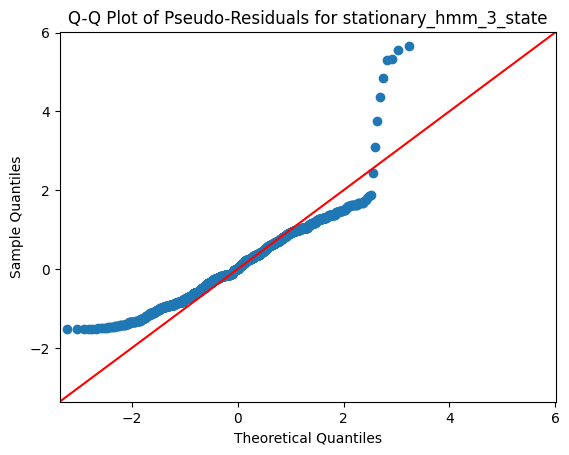

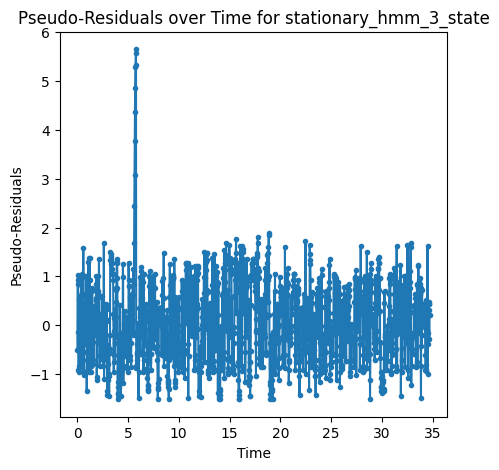

<Figure size 500x500 with 0 Axes>

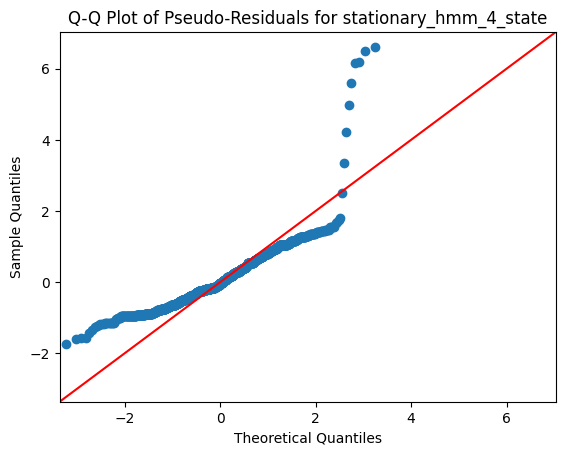

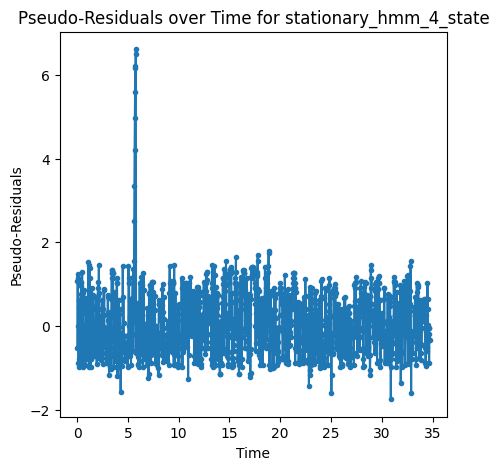

<Figure size 500x500 with 0 Axes>

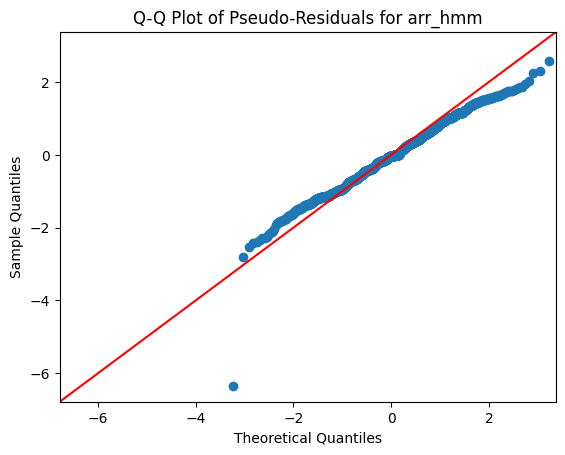

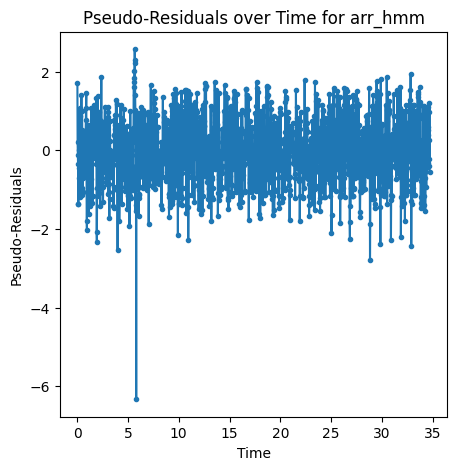

<Figure size 500x500 with 0 Axes>

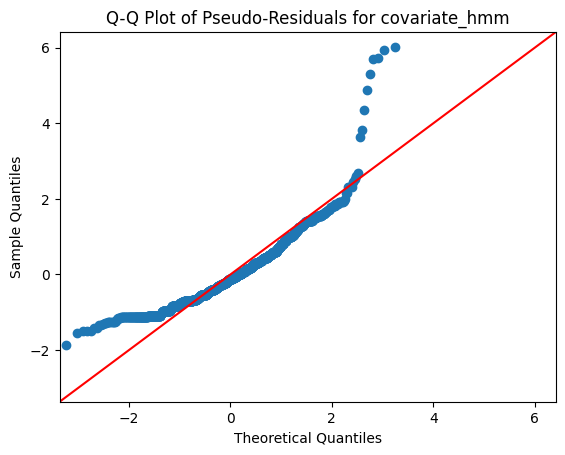

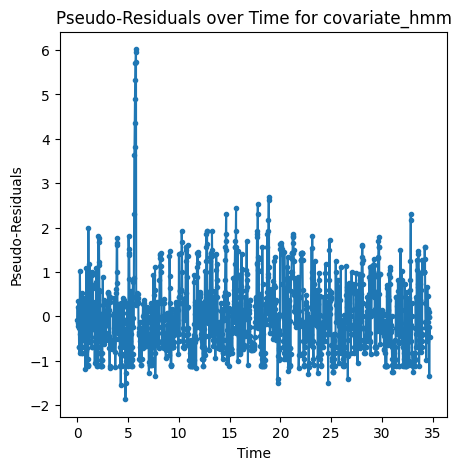

ValueError: Incompatible shapes for broadcasting: shapes=[(4, 6), (4,)]

In [13]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

time = df["Time"].values



for model_id in model_dict.keys():

    model = model_dict[model_id]["model"]  # Get the optimized model
    name = model_dict[model_id]["name"]
    X = model_dict[model_id]["X"]                                                                      
    pseudo_residuals = model.pseudo_residuals(y, X)   # needs yt[:, None] fix       

    #Plotting

    plt.figure(figsize=(5, 5))
    sm.qqplot(pseudo_residuals, line='45')
    plt.title(f"Q-Q Plot of Pseudo-Residuals for {name}")
    plt.show() 

    plt.figure(figsize=(5, 5))
    plt.plot(time, pseudo_residuals, marker='o', linestyle='-', markersize=3)
    plt.title(f"Pseudo-Residuals over Time for {name}")
    plt.xlabel("Time")
    plt.ylabel("Pseudo-Residuals")
    plt.show()                                                                


